In [1]:
# Setup

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

vocab = ['<bos>', 'a', 'b', 'c', '<eos>']
stoi = {c: i for i, c in enumerate(vocab)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(vocab)

In [2]:
# Task 1: Policy network

class CharPolicy(nn.Module):
    def __init__(self, embed_dim: int = 8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        emb = self.embedding(x)
        logits = self.linear(emb)
        return logits

In [3]:
# Task 2: Sampling

def sample(model: CharPolicy, max_len: int = 8) -> tuple[list[str], torch.Tensor]:
    seq = []
    log_probs = []

    current_token = torch.tensor([stoi['<bos>']], dtype=torch.long)

    for _ in range(max_len):
        logits = model(current_token)
        dist = torch.distributions.Categorical(logits=logits.squeeze(0))

        next_token = dist.sample()
        log_prob = dist.log_prob(next_token)

        token_str = itos[next_token.item()]

        seq.append(token_str)
        log_probs.append(log_prob)

        current_token = next_token.unsqueeze(0)

        if token_str == '<eos>':
            break

    return seq, torch.stack(log_probs)

In [4]:
# Task 3: Reward

def reward(seq: list[str]) -> float:
    s = ''.join(tok for tok in seq if tok != '<eos>')
    return 1.0 if 'abc' in s else 0.0

In [5]:
# Helper: moving average

def moving_average(xs, window=50):
    xs = torch.tensor(xs, dtype=torch.float32)

    if len(xs) < window:
        return xs.numpy()

    kernel = torch.ones(window) / window

    ma = torch.nn.functional.conv1d(
        xs.view(1, 1, -1),
        kernel.view(1, 1, -1)
    )

    return ma.view(-1).numpy()

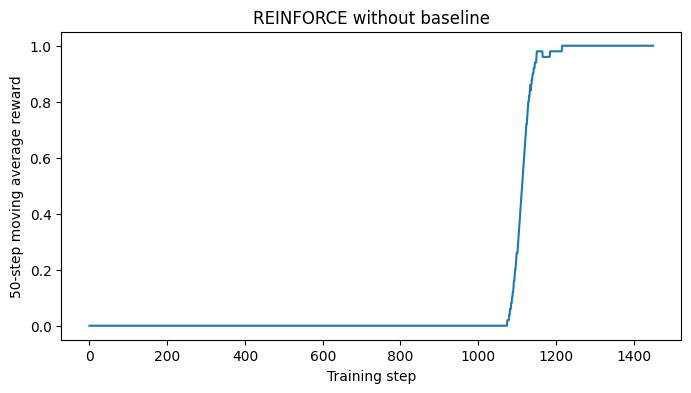

Final 100-step average reward without baseline: 1.0


In [6]:
# Task 4: REINFORCE without baseline

torch.manual_seed(0)

model_no_baseline = CharPolicy()
optimizer = optim.Adam(model_no_baseline.parameters(), lr=1e-2)

rewards_no_baseline: list[float] = []

for step in range(1500):
    seq, log_probs = sample(model_no_baseline)

    R = reward(seq)

    loss = -R * log_probs.sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    rewards_no_baseline.append(R)

plt.figure(figsize=(8, 4))
plt.plot(moving_average(rewards_no_baseline, window=50))
plt.title("REINFORCE without baseline")
plt.xlabel("Training step")
plt.ylabel("50-step moving average reward")
plt.show()

print("Final 100-step average reward without baseline:",
      sum(rewards_no_baseline[-100:]) / 100)

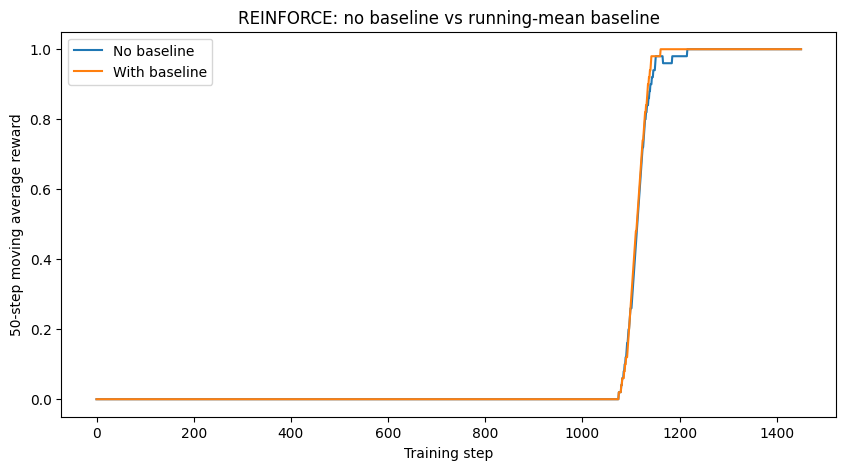

Final 100-step average reward with baseline: 1.0


In [7]:
# Task 4b: REINFORCE with running-mean baseline

torch.manual_seed(0)

model_with_baseline = CharPolicy()
optimizer = optim.Adam(model_with_baseline.parameters(), lr=1e-2)

rewards_with_baseline: list[float] = []
baseline = 0.0

for step in range(1500):
    seq, log_probs = sample(model_with_baseline)

    R = reward(seq)

    advantage = R - baseline

    loss = -advantage * log_probs.sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    baseline = 0.9 * baseline + 0.1 * R

    rewards_with_baseline.append(R)

plt.figure(figsize=(10, 5))
plt.plot(moving_average(rewards_no_baseline, 50), label="No baseline")
plt.plot(moving_average(rewards_with_baseline, 50), label="With baseline")
plt.title("REINFORCE: no baseline vs running-mean baseline")
plt.xlabel("Training step")
plt.ylabel("50-step moving average reward")
plt.legend()
plt.show()

print("Final 100-step average reward with baseline:",
      sum(rewards_with_baseline[-100:]) / 100)

In [8]:
# Task 5a: Inspect learned conditional distributions

model = model_with_baseline

contexts = ['<bos>', 'a', 'b', 'c']

with torch.no_grad():
    for ctx in contexts:
        x = torch.tensor([stoi[ctx]], dtype=torch.long)
        logits = model(x)
        probs = torch.softmax(logits, dim=-1).squeeze(0)

        print(f"\nπ(. | {ctx})")
        for tok, p in zip(vocab, probs):
            print(f"{tok:>6}: {p.item():.4f}")


π(. | <bos>)
 <bos>: 0.0016
     a: 0.9918
     b: 0.0024
     c: 0.0009
 <eos>: 0.0032

π(. | a)
 <bos>: 0.1018
     a: 0.0025
     b: 0.8918
     c: 0.0015
 <eos>: 0.0025

π(. | b)
 <bos>: 0.0003
     a: 0.0001
     b: 0.0001
     c: 0.9992
 <eos>: 0.0003

π(. | c)
 <bos>: 0.4949
     a: 0.0616
     b: 0.1802
     c: 0.1748
 <eos>: 0.0885


In [9]:
# Task 5b: Sample 10 trajectories

for i in range(10):
    seq, _ = sample(model_with_baseline)
    R = reward(seq)
    print(f"{i + 1}: {seq} | reward = {R}")

1: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'b'] | reward = 1.0
2: ['a', 'b', 'c', 'b', 'c', 'b', 'c', '<bos>'] | reward = 1.0
3: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'b'] | reward = 1.0
4: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', '<bos>'] | reward = 1.0
5: ['a', 'b', 'c', 'c', 'c', 'b', 'c', 'c'] | reward = 1.0
6: ['a', 'b', 'c', 'b', 'c', '<bos>', 'a', 'b'] | reward = 1.0
7: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'b'] | reward = 1.0
8: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', '<bos>'] | reward = 1.0
9: ['a', 'b', 'c', 'b', 'c', '<bos>', 'a', 'b'] | reward = 1.0
10: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'c'] | reward = 1.0


In [10]:
# Task 5c: Discussion

discussion = """
The first action receives gradient signal because the REINFORCE loss multiplies the terminal reward by the log-probability of every sampled action in the trajectory.
In particular, the loss contains the term -R(τ) * log π(a₁ | <bos>).
When a sampled sequence eventually receives reward 1 because it contains abc, the gradient increases the probability of all actions that contributed to that successful trajectory, including the very first decision after <bos>.
This is how temporal credit assignment works in policy gradients: even though the reward is delayed until the end, every earlier action in the trajectory is reinforced proportionally to the final return.
"""

print(discussion)


The first action receives gradient signal because the REINFORCE loss multiplies the terminal reward by the log-probability of every sampled action in the trajectory.
In particular, the loss contains the term -R(τ) * log π(a₁ | <bos>).
When a sampled sequence eventually receives reward 1 because it contains abc, the gradient increases the probability of all actions that contributed to that successful trajectory, including the very first decision after <bos>.
This is how temporal credit assignment works in policy gradients: even though the reward is delayed until the end, every earlier action in the trajectory is reinforced proportionally to the final return.

